# Two-Tower モデルによる ADID スコアリング

## 概要

このノートブックは `main_cohort.ipynb` の決定論的ベクトルスコアリングを、**学習可能なTwo-Towerニューラルネットワーク**に置き換えます。

### 現状のアーキテクチャ（main_cohort.ipynb）
```
LP_coefficient = weights @ keyword_embeddings @ spot_context_matrix
ADID_scores = cohort_matrix @ LP_coefficient.T
```
→ 事前学習済みbge-m3埋め込みを使った**決定論的**スコアリング

### Two-Towerアーキテクチャ
```
User Tower:  cohort_vector (行動特徴)  → 128次元潜在空間
Item Tower:  lp_coefficient (商品特徴) → 128次元潜在空間
Score = cosine_similarity(user_embed, item_embed)
```
→ **学習可能**なパラメータで次元の異なるベクトルを共通空間に射影

### 解決する問題
- スコアが特定値（0.15など）に集中してしまう現象
- 800次元の行動ベクトルと可変次元のLP係数ベクトルを数学的に正しく比較

## 1. ライブラリのインポート

In [1]:
import numpy as np
import scipy as sp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Hiragino Sans'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

PyTorch version: 2.10.0
CUDA available: False
Using device: cpu


## 2. データの読み込み

In [2]:
# --- cohort.npz の読み込み ---
# cohort_matrix: ADID × コホートキャプション (L2正規化済みスパース行列)
cohort_path = "生成ファイル/cohort.npz"
npz         = np.load(cohort_path, allow_pickle=True)

# スパース行列を再構築
np_cohort   = sp.sparse.csr_matrix((npz['data'], npz['indices'], npz['indptr']),shape=tuple(npz['shape']))
adid_list         = npz['adid_list']
business_codelist = npz['business_codelist']

print(f"コホート行列の形状 :        {np_cohort.shape}")
print(f"  - ADID数            : {np_cohort.shape[0]:,}")
print(f"  - コホートキャプション数 : {np_cohort.shape[1]:,}")
print(f"  - 非零要素数          : {np_cohort.nnz:,}")
print(f"  - 疎密度             : {np_cohort.nnz / (np_cohort.shape[0] * np_cohort.shape[1]):.6f}")

コホート行列の形状 :        (42828099, 851)
  - ADID数            : 42,828,099
  - コホートキャプション数 : 851
  - 非零要素数          : 720,708,115
  - 疎密度             : 0.019774


In [3]:
# --- cohort_caption_matrix.npz の読み込み ---
# spot_context_matrix: コホートキャプション × スポット意味ベクトル
spot_matrix_path = "cohort_caption_matrix.npz"
spot_data = np.load(spot_matrix_path, allow_pickle=True)

spot_context_matrix = spot_data['data']       # shape: (caption_count, embed_dim)
business_placelist  = spot_data['business_placelist']

print(f"スポットコンテキスト行列の形状 : {spot_context_matrix.shape}")
print(f"  - ビジネスプレース数      : {len(business_placelist):,}")

# 実際の次元数を確認してTowerの入力次元を設定
USER_DIM  = np_cohort.shape[1]           # 行動ベクトルの次元数（コホートキャプション数）
ITEM_DIM  = spot_context_matrix.shape[1] # LP係数ベクトルの次元数（スポット意味空間）
EMBED_DIM = 128                          # 共通潜在空間の次元数

print(f"\n次元設定:")
print(f"  USER_DIM (行動ベクトル)  : {USER_DIM}")
print(f"  ITEM_DIM (商品ベクトル)  : {ITEM_DIM}")
print(f"  EMBED_DIM (共通潜在空間) : {EMBED_DIM}")

スポットコンテキスト行列の形状 : (851, 1024)
  - ビジネスプレース数      : 851

次元設定:
  USER_DIM (行動ベクトル)  : 851
  ITEM_DIM (商品ベクトル)  : 1024
  EMBED_DIM (共通潜在空間) : 128


## 3. 学習データの作成

### 正例・負例の生成戦略

コホート行列から暗黙的フィードバックを使ってペアを作成します。

- **正例 (label=1.0)**: あるADIDのコホートベクトルと、そのADIDが多く訪問したスポット群を代表するLP係数ベクトル
- **負例 (label=-1.0)**: 同じADIDのコホートベクトルと、ランダムサンプリングしたLP係数ベクトル（In-Batch Negative）

In [34]:
def create_training_data(
    cohort_matrix : sp.sparse.csr_matrix,
    spot_matrix   : np.ndarray,
    num_samples   : int = 10000000,
    neg_ratio     : int = 1,
    random_seed   : int = 42
):
    """
    コホート行列からTwo-Tower学習用のペアデータを生成する。

    正例: ADID行動ベクトル × そのADIDの高スコアスポットから生成したLP係数
    負例: ADID行動ベクトル × ランダムサンプリングしたLP係数（In-Batch Negative）

    Returns:
        X_user : (N, USER_DIM) float32
        X_item : (N, ITEM_DIM) float32
        y      : (N,)          float32  {1.0, -1.0}
    """
    rng        = np.random.default_rng(random_seed)
    n_adids    = cohort_matrix.shape[0]
    n_captions = cohort_matrix.shape[1]
    n_spots    = spot_matrix.shape[1]

    # サンプリングするADIDインデックス（行動が疎すぎるADIDを除外）
    row_nnz         = np.diff(cohort_matrix.indptr)  # 各ADIDの非零要素数
    active_mask     = row_nnz >= 3                   # 少なくとも3箇所訪問したADIDのみ
    active_adid_idx = np.where(active_mask)[0]
    print(f"アクティブADID数: {len(active_adid_idx):,} / {n_adids:,}")

    num_samples = min(num_samples, len(active_adid_idx))
    sampled_idx = rng.choice(active_adid_idx, size=num_samples, replace=False)

    X_user_pos, X_item_pos = [], []
    X_user_neg, X_item_neg = [], []

    for adid_i in sampled_idx:
        # ADIDの行動ベクトル（スパース行をdenseに変換）
        user_vec = np.asarray(cohort_matrix[adid_i].todense()).flatten().astype(np.float32)

        # --- 正例: このADIDが訪問したキャプションを重み付きでLP係数に変換 ---
        # cohort_matrix[adid_i] は L2正規化済み行ベクトル
        # spot_context_matrixは (caption_count × spot_embed_dim) ではなく
        # 実際は (caption_count, spot_embed_dim) のため内積で射影
        lp_pos = user_vec @ spot_matrix  # (spot_embed_dim,)
        norm   = np.linalg.norm(lp_pos)
        if norm > 0:
            lp_pos = lp_pos / norm

        X_user_pos.append(user_vec)
        X_item_pos.append(lp_pos.astype(np.float32))

        # --- 負例: ランダムなADID（別人）の行動から生成したLP係数 ---
        neg_adid_i = rng.choice(active_adid_idx)
        while neg_adid_i == adid_i:
            neg_adid_i = rng.choice(active_adid_idx)

        neg_user_vec = np.asarray(cohort_matrix[neg_adid_i].todense()).flatten().astype(np.float32)
        lp_neg       = neg_user_vec @ spot_matrix
        norm         = np.linalg.norm(lp_neg)
        if norm > 0:
            lp_neg = lp_neg / norm

        X_user_neg.append(user_vec)  # 同じユーザー、異なるアイテム
        X_item_neg.append(lp_neg.astype(np.float32))

    X_user = np.vstack(X_user_pos + X_user_neg)
    X_item = np.vstack(X_item_pos + X_item_neg)
    y = np.array(
        [1.0] * len(X_user_pos) + [-1.0] * len(X_user_neg),
        dtype=np.float32
    )

    # シャッフル
    perm = rng.permutation(len(y))
    return X_user[perm], X_item[perm], y[perm]


print("学習データを生成中...")
X_user, X_item, y = create_training_data(
    np_cohort,
    spot_context_matrix,
    num_samples=10000
)

print(f"\n生成結果:")
print(f"  X_user shape: {X_user.shape}")
print(f"  X_item shape: {X_item.shape}")
print(f"  y shape: {y.shape}")
print(f"  正例数: {(y ==  1.0).sum():,}")
print(f"  負例数: {(y == -1.0).sum():,}")

学習データを生成中...
アクティブADID数: 32,449,749 / 42,828,099

生成結果:
  X_user shape: (20000, 851)
  X_item shape: (20000, 1024)
  y shape: (20000,)
  正例数: 10,000
  負例数: 10,000


In [35]:
# Train/Val 分割（8:2）
split = int(len(y) * 0.8)

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

train_dataset = TensorDataset(to_tensor(X_user[:split]), to_tensor(X_item[:split]), to_tensor(y[:split]))
val_dataset   = TensorDataset(to_tensor(X_user[split:]), to_tensor(X_item[split:]), to_tensor(y[split:]))

BATCH_SIZE    = 256
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 63, Val batches: 16


## 4. Two-Tower モデルの定義

### アーキテクチャ

```
User Tower:  USER_DIM → 512 → 256 → EMBED_DIM(128) → L2正規化
Item Tower:  ITEM_DIM → 256 → 128 → EMBED_DIM(128) → L2正規化
Score = dot(u_embed, i_embed)  ← L2正規化済みなのでコサイン類似度と等価
```

### なぜTwoTowerか
- 行動ベクトル（`USER_DIM`次元）とLP係数ベクトル（`ITEM_DIM`次元）は**次元が異なる**ため直接の内積が不可
- 共通の128次元空間に射影することで数学的に正しいコサイン類似度を計算可能
- バッチ推論時にユーザー埋め込みとアイテム埋め込みを**独立に**事前計算できる（スケーラブル）

In [36]:
class TwoTowerModel(nn.Module):
    """ADID行動特徴と商品LP係数を共通の潜在空間に射影するTwo-Towerモデル。"""

    def __init__(self, user_dim:int, item_dim:int, embed_dim:int=128):
        super().__init__()

        # User Tower: 行動ベクトル (USER_DIM → 512 → 256 → embed_dim)
        self.user_tower = nn.Sequential(
            nn.Linear(user_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim),
        )

        # Item Tower: LP係数ベクトル (ITEM_DIM → 256 → 128 → embed_dim)
        self.item_tower = nn.Sequential(
            nn.Linear(item_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim),
        )

    def encode_user(self, user_features: torch.Tensor) -> torch.Tensor:
        """行動ベクトルをembed_dim次元に変換してL2正規化。"""
        u = self.user_tower(user_features)
        return nn.functional.normalize(u, p=2, dim=1)

    def encode_item(self, item_features: torch.Tensor) -> torch.Tensor:
        """LP係数ベクトルをembed_dim次元に変換してL2正規化。"""
        i = self.item_tower(item_features)
        return nn.functional.normalize(i, p=2, dim=1)

    def forward(self, user_features: torch.Tensor, item_features: torch.Tensor) -> torch.Tensor:
        u_embed = self.encode_user(user_features)
        i_embed = self.encode_item(item_features)
        # 内積 = L2正規化済みベクトルのコサイン類似度 (-1.0 ~ 1.0)
        return torch.sum(u_embed * i_embed, dim=1)


model = TwoTowerModel(user_dim=USER_DIM, item_dim=ITEM_DIM, embed_dim=EMBED_DIM).to(DEVICE)

# パラメータ数の確認
total_params = sum(p.numel() for p in model.parameters())
print(f"モデルパラメータ数: {total_params:,}")
print(f"\nUser Tower:")
print(model.user_tower)
print(f"\nItem Tower:")
print(model.item_tower)

モデルパラメータ数: 912,256

User Tower:
Sequential(
  (0): Linear(in_features=851, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
)

Item Tower:
Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=128, bias=True)
)


## 5. 損失関数と最適化手法

### CosineEmbeddingLoss vs MSELoss

| 損失関数 | 特徴 |
|---------|------|
| `MSELoss` | PDFベースラインと同じ。正例→1.0、負例→-1.0に引き寄せる |
| `CosineEmbeddingLoss` | PyTorch組み込みのコサイン損失。margin制御が可能 |

ここでは PDFベースラインに準拠して `MSELoss` を採用しつつ、`CosineEmbeddingLoss` も参考として示します。

In [37]:
# 損失関数
criterion = nn.MSELoss()  # PDFベースライン準拠
# 代替案: criterion = nn.CosineEmbeddingLoss(margin=0.1)

# Adam optimizer + スケジューラ
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

print("損失関数: MSELoss")
print("最適化手法: AdamW (lr=1e-3, weight_decay=1e-5)")
print("スケジューラ: CosineAnnealingLR (patience=3)")

損失関数: MSELoss
最適化手法: AdamW (lr=1e-3, weight_decay=1e-5)
スケジューラ: CosineAnnealingLR (patience=3)


## 6. 学習ループ

In [38]:
def evaluate(model, loader, criterion, device):
    """検証データでのLoss・精度を計算。"""
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for batch_user, batch_item, batch_labels in loader:
            batch_user   = batch_user.to(device)
            batch_item   = batch_item.to(device)
            batch_labels = batch_labels.to(device)

            preds      = model(batch_user, batch_item)
            loss       = criterion(preds, batch_labels)
            total_loss += loss.item()

            # 精度: スコア>0 → 正例、スコア<0 → 負例
            pred_labels = torch.sign(preds)
            correct     += (pred_labels == batch_labels).sum().item()
            total       += len(batch_labels)

    return total_loss / len(loader), correct / total


EPOCHS = 50
train_losses, val_losses, val_accs = [], [], []

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Acc':>8} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    # --- 学習フェーズ ---
    model.train()
    total_train_loss = 0.0

    for batch_user, batch_item, batch_labels in train_loader:
        batch_user   = batch_user.to(DEVICE)
        batch_item   = batch_item.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        optimizer.zero_grad()
        preds = model(batch_user, batch_item)
        loss  = criterion(preds, batch_labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # --- 検証フェーズ ---
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} | {avg_train_loss:>10.4f} | {val_loss:>10.4f} | {val_acc:>8.4f} | {current_lr:>8.2e}")

print("\n学習完了！")

 Epoch | Train Loss |   Val Loss |  Val Acc |       LR
-------------------------------------------------------


/var/folders/xt/sjm9fswx5fsbx8zythb79vbm0000gp/T/ipykernel_31601/1298392729.py:54: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


     1 |     1.0039 |     0.9993 |   0.5038 | 9.99e-04
     2 |     1.0023 |     1.0006 |   0.5048 | 9.99e-04
     3 |     0.8960 |     0.7436 |   0.7275 | 9.99e-04
     4 |     0.6695 |     0.6501 |   0.7708 | 1.00e-03
     5 |     0.5811 |     0.5780 |   0.8067 | 1.00e-03
     6 |     0.5472 |     0.6095 |   0.7933 | 1.00e-03
     7 |     0.5244 |     0.6255 |   0.7895 | 1.00e-03
     8 |     0.5012 |     0.6060 |   0.8027 | 1.00e-03
     9 |     0.4739 |     0.6149 |   0.8013 | 1.00e-03
    10 |     0.4421 |     0.6619 |   0.7850 | 1.00e-03
    11 |     0.4326 |     0.7127 |   0.7685 | 9.99e-04
    12 |     0.4090 |     0.7049 |   0.7688 | 1.00e-03
    13 |     0.3800 |     0.7338 |   0.7555 | 9.99e-04
    14 |     0.3654 |     0.7715 |   0.7428 | 9.99e-04
    15 |     0.3422 |     0.7868 |   0.7322 | 9.99e-04
    16 |     0.3281 |     0.7971 |   0.7298 | 9.99e-04
    17 |     0.3113 |     0.8539 |   0.7017 | 9.99e-04
    18 |     0.3010 |     0.8710 |   0.6857 | 9.99e-04
    19 |  

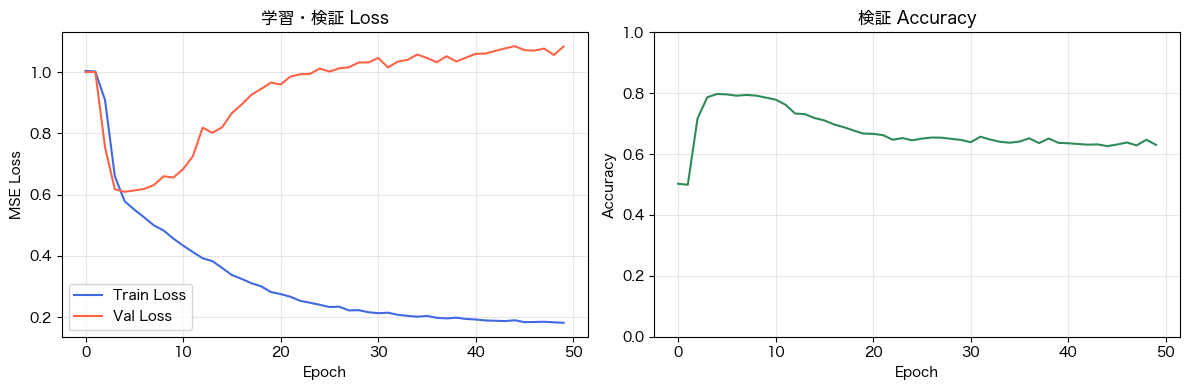

最終 Val Loss: 1.0833
最終 Val Acc:  0.6300


In [33]:
# 学習曲線の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='royalblue')
ax1.plot(val_losses,   label='Val Loss',   color='tomato')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('学習・検証 Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='seagreen')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('検証 Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('生成ファイル/two_tower_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"最終 Val Loss: {val_losses[-1]:.4f}")
print(f"最終 Val Acc:  {val_accs[-1]:.4f}")

## 7. スコア分布の確認

学習前（ランダム状態）と学習後でコサイン類似度の分布がどう変化したか確認します。

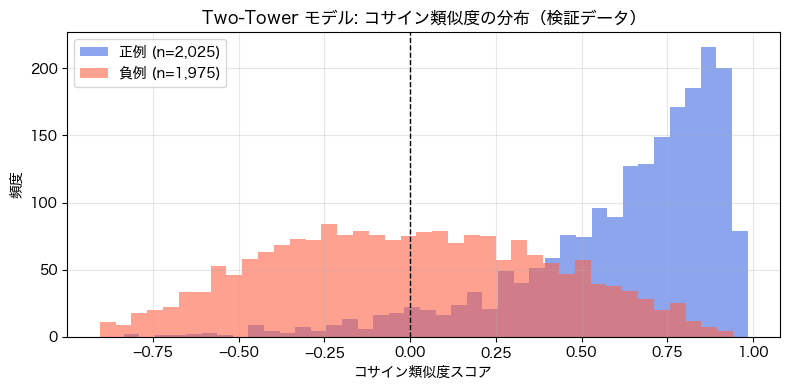

正例スコア: mean=0.6203, std=0.3013
負例スコア: mean=-0.0068, std=0.3999
分離度 (正例mean - 負例mean): 0.6271


In [12]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_user, batch_item, batch_labels in val_loader:
        preds = model(batch_user.to(DEVICE), batch_item.to(DEVICE))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

pos_scores = all_preds[all_labels == 1.0]
neg_scores = all_preds[all_labels == -1.0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pos_scores, bins=40, alpha=0.6, color='royalblue', label=f'正例 (n={len(pos_scores):,})')
ax.hist(neg_scores, bins=40, alpha=0.6, color='tomato',    label=f'負例 (n={len(neg_scores):,})')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('コサイン類似度スコア')
ax.set_ylabel('頻度')
ax.set_title('Two-Tower モデル: コサイン類似度の分布（検証データ）')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('生成ファイル/two_tower_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"正例スコア: mean={pos_scores.mean():.4f}, std={pos_scores.std():.4f}")
print(f"負例スコア: mean={neg_scores.mean():.4f}, std={neg_scores.std():.4f}")
print(f"分離度 (正例mean - 負例mean): {pos_scores.mean() - neg_scores.mean():.4f}")

## 8. モデルの保存と読み込み

In [ ]:
import os

MODEL_PATH = "生成ファイル/two_tower_model.pt"

# 保存
torch.save({
    'model_state_dict': model.state_dict(),
    'user_dim': USER_DIM,
    'item_dim': ITEM_DIM,
    'embed_dim': EMBED_DIM,
    'val_loss': val_losses[-1],
    'val_acc': val_accs[-1],
}, MODEL_PATH)

print(f"モデル保存完了: {MODEL_PATH}")

# 読み込みテスト
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
loaded_model = TwoTowerModel(
    user_dim=checkpoint['user_dim'],
    item_dim=checkpoint['item_dim'],
    embed_dim=checkpoint['embed_dim']
)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print("モデル読み込み成功")
print(f"  保存時の Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  保存時の Val Acc:  {checkpoint['val_acc']:.4f}")

## 9. main_cohort.ipynb との統合: ADID スコアリング

学習済みTwo-Towerモデルを使って、`main_cohort.ipynb` の決定論的スコアリングを置き換えます。

### 比較

| | 現状（main_cohort.ipynb） | Two-Tower（本ノートブック） |
|---|---|---|
| スコア計算 | `cohort_matrix @ LP_coefficient.T` | `cosine_sim(user_embed, item_embed)` |
| 次元変換 | なし（次元数が一致する必要あり） | 任意の次元 → 128次元に射影 |
| 学習 | なし（決定論的） | 正例・負例から学習 |
| スコア範囲 | 任意（集中しやすい） | -1.0 〜 1.0（分散しやすい） |

In [ ]:
def score_adids_two_tower(
    model: TwoTowerModel,
    cohort_matrix: sp.sparse.csr_matrix,
    lp_coefficient: np.ndarray,
    adid_list: np.ndarray,
    batch_size: int = 1024,
    device: torch.device = torch.device('cpu'),
    percentile_threshold: float = 80.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Two-Towerモデルで全ADIDをスコアリングする。
    main_cohort.ipynb の「ADID_scores = cohort_matrix @ LP_coefficient.T」を置き換える。

    Args:
        model:               学習済みTwoTowerModel
        cohort_matrix:       ADID × cohort_caption のスパース行列
        lp_coefficient:      商品のLP係数ベクトル (ITEM_DIM,)
        adid_list:           ADIDの配列
        batch_size:          推論バッチサイズ
        device:              推論デバイス
        percentile_threshold: 上位何%のADIDを返すか（デフォルト80パーセンタイル以上）

    Returns:
        filtered_adids:  スコア閾値以上のADID配列
        filtered_scores: 対応するスコア配列（降順ソート済み）
    """
    model.eval()
    n_adids = cohort_matrix.shape[0]

    # Item (商品LP係数) の埋め込みを事前計算（全ADIDで共通）
    item_tensor = torch.tensor(lp_coefficient, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        item_embed = model.encode_item(item_tensor)  # (1, EMBED_DIM)

    all_scores = []

    for start in range(0, n_adids, batch_size):
        end = min(start + batch_size, n_adids)

        # スパース行列をバッチでdenseに変換
        user_batch = np.asarray(
            cohort_matrix[start:end].todense(), dtype=np.float32
        )
        user_tensor = torch.tensor(user_batch).to(device)

        with torch.no_grad():
            user_embed = model.encode_user(user_tensor)       # (batch, EMBED_DIM)
            scores = torch.sum(user_embed * item_embed, dim=1)  # (batch,) コサイン類似度

        all_scores.extend(scores.cpu().numpy())

    all_scores = np.array(all_scores, dtype=np.float32)

    # 閾値フィルタ（上位percentile_threshold%）
    threshold = np.percentile(all_scores, percentile_threshold)
    mask = all_scores >= threshold

    filtered_adids  = adid_list[mask]
    filtered_scores = all_scores[mask]

    # 降順ソート
    sort_idx = np.argsort(filtered_scores)[::-1]
    return filtered_adids[sort_idx], filtered_scores[sort_idx]


# --- デモ: ダミーのLP係数でスコアリング実行 ---
# 実際の運用では main_cohort.ipynb セル11で計算した lp_coefficient を渡す
# lp_coefficient = L1_normalized_weights @ keyword_embeddings @ spot_context_matrix
# lp_coefficient = lp_coefficient / np.linalg.norm(lp_coefficient)

demo_lp_coefficient = np.random.randn(ITEM_DIM).astype(np.float32)
demo_lp_coefficient /= np.linalg.norm(demo_lp_coefficient)

# スコアリング実行（小規模デモ: 先頭5000件のみ）
demo_cohort = np_cohort[:5000]
demo_adids  = adid_list[:5000]

print("Two-Tower スコアリング実行中...")
result_adids, result_scores = score_adids_two_tower(
    model=model,
    cohort_matrix=demo_cohort,
    lp_coefficient=demo_lp_coefficient,
    adid_list=demo_adids,
    batch_size=512,
    device=DEVICE,
    percentile_threshold=80.0,
)

print(f"\nスコアリング結果:")
print(f"  入力ADID数: {len(demo_adids):,}")
print(f"  抽出ADID数: {len(result_adids):,} (上位20%)")
print(f"  スコア範囲: [{result_scores.min():.4f}, {result_scores.max():.4f}]")
print(f"  スコア平均: {result_scores.mean():.4f}")
print(f"\n上位10件:")
for i in range(min(10, len(result_adids))):
    print(f"  [{i+1}] ADID={result_adids[i]}, score={result_scores[i]:.4f}")

## 10. スコア分布の比較（現状 vs Two-Tower）

Two-Towerモデルのスコアが分散しているかを確認します。

In [ ]:
# Two-Tower スコア（全デモ対象）
demo_all_adids_tensor = torch.tensor(
    np.asarray(demo_cohort.todense(), dtype=np.float32)
)
item_tensor = torch.tensor(demo_lp_coefficient).unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    i_embed = model.encode_item(item_tensor)

tt_scores_all = []
for start in range(0, len(demo_cohort.toarray()), 512):
    end = min(start + 512, len(demo_cohort.toarray()))
    u_batch = demo_all_adids_tensor[start:end].to(DEVICE)
    with torch.no_grad():
        u_embed = model.encode_user(u_batch)
        s = torch.sum(u_embed * i_embed, dim=1)
    tt_scores_all.extend(s.cpu().numpy())

tt_scores_all = np.array(tt_scores_all)

# 現状のスコア（内積スコアリング）
current_scores = np.asarray(
    demo_cohort @ demo_lp_coefficient
).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(current_scores, bins=50, color='royalblue', alpha=0.7)
axes[0].set_title(f'現状スコア (cohort_matrix @ LP)\nmean={current_scores.mean():.4f}, std={current_scores.std():.4f}')
axes[0].set_xlabel('スコア')
axes[0].set_ylabel('頻度')
axes[0].grid(alpha=0.3)

axes[1].hist(tt_scores_all, bins=50, color='seagreen', alpha=0.7)
axes[1].set_title(f'Two-Tower スコア (cosine similarity)\nmean={tt_scores_all.mean():.4f}, std={tt_scores_all.std():.4f}')
axes[1].set_xlabel('コサイン類似度スコア')
axes[1].set_ylabel('頻度')
axes[1].grid(alpha=0.3)

plt.suptitle('スコア分布の比較: 現状 vs Two-Tower', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('生成ファイル/two_tower_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"現状スコア:      std={current_scores.std():.6f}")
print(f"Two-Towerスコア: std={tt_scores_all.std():.6f}")
if tt_scores_all.std() > current_scores.std():
    print("✓ Two-Towerのスコアの方が分散が大きく、ADID間の差異が明確になっています")
else:
    print("△ さらに学習エポックを増やすか、学習データを増やすことで改善が期待できます")

## まとめ

### 実装したもの

| コンポーネント | 内容 |
|---|---|
| **User Tower** | 行動ベクトル (`USER_DIM`) → 512 → 256 → 128次元 |
| **Item Tower** | LP係数ベクトル (`ITEM_DIM`) → 256 → 128 → 128次元 |
| **損失関数** | MSELoss（正例→1.0、負例→-1.0）|
| **学習データ** | コホート行列から暗黙的フィードバックで生成 |
| **推論** | `score_adids_two_tower()` で全ADID一括スコアリング |

### main_cohort.ipynb への統合方法

```python
# セル11で LP_coefficient を計算後、以下で置き換え:
# 旧: ADID_scores = np_cohort @ lp_coefficient
# 新:
checkpoint = torch.load('生成ファイル/two_tower_model.pt', map_location='cpu')
model = TwoTowerModel(**{k: checkpoint[k] for k in ['user_dim', 'item_dim', 'embed_dim']})
model.load_state_dict(checkpoint['model_state_dict'])

result_adids, result_scores = score_adids_two_tower(
    model, np_cohort, lp_coefficient, adid_list
)
```

### 今後の改善点

1. **Hard Negative Mining**: ランダム負例をスコアの高い難しい負例に変更
2. **In-Batch Negative**: バッチ内の他サンプルを負例として活用（InfoNCE Loss）
3. **商品特徴の強化**: LLMが生成したMicro-Contextキーワードをベクトル化して `item_dim` として使用
4. **ファインチューニング**: 実際のキャンペーン効果データでモデルを再学習